# MLP Forecasting Pipeline

This notebook mirrors the data loading, preprocessing, target, and chronological split philosophy from `LSTM.ipynb`, but replaces the 60-step sequence model with a tabular MLP. Each row is treated as one contract-time snapshot and the model predicts the next 5-second return.

In [16]:
# ==========================================
# 1. Imports
# ==========================================
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

plt.style.use("seaborn-v0_8-whitegrid")

In [17]:
# ==========================================
# 2. Config
# ==========================================
CONFIG = {
    "data_path": "../data/LSTM_DATA_WITH_PRICE.parquet",
    "target_candidates": ["Target_5s_Return", "future_return_5s"],
    "seed": 42,
    "test_quantile": 0.85,
    "val_quantile_within_base": 0.85,
    "clip_val": 10.0,
    "batch_size": 2048,
    "epochs": 50,
    "patience": 8,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "grad_clip": 1.0,
    "hidden_dims": [256, 128, 64],
    "dropout": 0.20,
    "use_batch_norm": True,
    "taker_fee_rate": 0.072,
    "upper_quantile": 0.90,
    "lower_quantile": 0.10,
    "direction_epsilon": 1e-5,
    "model_path": "../models/best_alpha_mlp.pth",
}


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    if hasattr(torch, "use_deterministic_algorithms"):
        torch.use_deterministic_algorithms(True, warn_only=True)


set_seed(CONFIG["seed"])

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

mps_available = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if mps_available else "cpu")

print(f"Using device: {device}")
print(f"Checkpoint file: {Path(CONFIG['model_path']).resolve()}")


Using device: mps
Checkpoint file: /Users/moryshi/Projects/fintech/540 Machine Learning/PolyMarket analysis - inverse reinforcement learning/models/best_alpha_mlp.pth


In [18]:
# ==========================================
# 3. Data loading
# Same parquet source and backtest metadata logic as LSTM.ipynb.
# ==========================================
data = pd.read_parquet(CONFIG["data_path"]).copy()

required_cols = {"slug", "timestamp"}
missing_required = sorted(required_cols.difference(data.columns))
if missing_required:
    raise KeyError(f"Missing required columns: {missing_required}")

TARGET_COL = next((col for col in CONFIG["target_candidates"] if col in data.columns), None)
if TARGET_COL is None:
    raise KeyError(f"Could not find target column. Tried: {CONFIG['target_candidates']}")

data["timestamp"] = pd.to_datetime(data["timestamp"])
data = data.sort_values(["timestamp", "slug"]).reset_index(drop=True)

execution_price_candidates = [
    "execution_price",
    "Up_Mid_Price",
    "price",
    "Up_trade_close",
    "Up_micro_price",
]
execution_price_col = next((col for col in execution_price_candidates if col in data.columns), None)
if execution_price_col is None:
    print(
        "⚠️ No execution price column found. Backtest metadata will keep an execution_price field, but values will be NaN until ../data/LSTM_DATA_WITH_PRICE.parquet includes price data."
    )
else:
    print(f"💵 execution_price source column: {execution_price_col}")

meta_cols = ["slug", "timestamp", TARGET_COL]
if execution_price_col is not None:
    meta_cols.append(execution_price_col)
feature_cols = [col for col in data.columns if col not in meta_cols]

if not feature_cols:
    raise ValueError("No feature columns found after excluding slug, timestamp, target, and execution price.")

non_numeric_features = data[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_features:
    raise TypeError(f"All MLP features must be numeric. Found: {non_numeric_features[:10]}")

missing_model_rows = int(data[feature_cols + [TARGET_COL]].isna().any(axis=1).sum())
if missing_model_rows:
    raise ValueError(
        f"Found {missing_model_rows} rows with missing features or target in the parquet data."
    )

print(f"Loaded shape: {data.shape}")
print(f"Target column: {TARGET_COL}")
print(f"Feature count: {len(feature_cols)}")
print(f"Unique contracts: {data['slug'].nunique()}")
print(f"Timestamp range: {data['timestamp'].min()} -> {data['timestamp'].max()}")

preview_cols = ["slug", "timestamp", TARGET_COL]
if execution_price_col is not None:
    preview_cols.append(execution_price_col)
preview_cols += feature_cols[:5]
print(data[preview_cols].head())


💵 execution_price source column: execution_price
Loaded shape: (450747, 25)
Target column: Target_5s_Return
Feature count: 21
Unique contracts: 657
Timestamp range: 2025-12-01 06:01:31+00:00 -> 2025-12-15 03:14:24+00:00
                        slug                 timestamp  Target_5s_Return  \
0  btc-updown-15m-1764568800 2025-12-01 06:01:31+00:00          0.062893   
1  btc-updown-15m-1764568800 2025-12-01 06:01:32+00:00          0.037037   
2  btc-updown-15m-1764568800 2025-12-01 06:01:33+00:00          0.024540   
3  btc-updown-15m-1764568800 2025-12-01 06:01:34+00:00          0.000000   
4  btc-updown-15m-1764568800 2025-12-01 06:01:35+00:00          0.018293   

   execution_price   moneyness  time_to_expiry  Micro_Price_Imbalance  \
0            0.795  140.658783           809.0              -0.001939   
1            0.810  140.658783           808.0              -0.002684   
2            0.815  145.819987           807.0              -0.002711   
3            0.815  146.008138 

In [19]:
# ==========================================
# 4. Chronological split
# Same split philosophy as the LSTM notebook:
# - sort globally by timestamp
# - most recent 15% remains test
# - training and validation only use earlier data
# ==========================================
test_cutoff = data["timestamp"].quantile(CONFIG["test_quantile"])

df_base = data[data["timestamp"] <= test_cutoff].copy()
df_test = data[data["timestamp"] > test_cutoff].copy()

val_cutoff = df_base["timestamp"].quantile(CONFIG["val_quantile_within_base"])
df_train = df_base[df_base["timestamp"] <= val_cutoff].copy()
df_val = df_base[df_base["timestamp"] > val_cutoff].copy()

split_frames = {
    "train": df_train,
    "val": df_val,
    "test": df_test,
}

for split_name, frame in split_frames.items():
    if frame.empty:
        raise ValueError(f"{split_name} split is empty. Adjust the time split configuration.")

print(f"Base size (train + val): {len(df_base):,}")
print(f"Train size: {len(df_train):,}")
print(f"Val size:   {len(df_val):,}")
print(f"Test size:  {len(df_test):,}")
print(f"Train range: {df_train['timestamp'].min()} -> {df_train['timestamp'].max()}")
print(f"Val range:   {df_val['timestamp'].min()} -> {df_val['timestamp'].max()}")
print(f"Test range:  {df_test['timestamp'].min()} -> {df_test['timestamp'].max()}")
print(
    "Unique contracts | "
    f"Train: {df_train['slug'].nunique()} | "
    f"Val: {df_val['slug'].nunique()} | "
    f"Test: {df_test['slug'].nunique()}"
)

Base size (train + val): 383,135
Train size: 325,664
Val size:   57,471
Test size:  67,612
Train range: 2025-12-01 06:01:31+00:00 -> 2025-12-12 11:37:08+00:00
Val range:   2025-12-12 11:37:09+00:00 -> 2025-12-13 17:02:57+00:00
Test range:  2025-12-13 17:02:58+00:00 -> 2025-12-15 03:14:24+00:00
Unique contracts | Train: 480 | Val: 83 | Test: 96


In [20]:
# ==========================================
# 5. Scaling and tabular sample construction
# MLP change vs LSTM: each row is one sample, so no rolling
# 60-second sequence creation is used here.
# ==========================================
scaler = RobustScaler()
CLIP_VAL = CONFIG["clip_val"]

df_train.loc[:, feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_val.loc[:, feature_cols] = scaler.transform(df_val[feature_cols])
df_test.loc[:, feature_cols] = scaler.transform(df_test[feature_cols])

for frame in (df_train, df_val, df_test):
    frame.loc[:, feature_cols] = np.clip(frame[feature_cols], -CLIP_VAL, CLIP_VAL)


def create_tabular_samples(df, feature_cols, target_col, execution_price_col=None):
    X = df[feature_cols].to_numpy(dtype=np.float32)
    y = df[target_col].to_numpy(dtype=np.float32)

    meta_cols = ["slug", "timestamp"]
    if execution_price_col is not None and execution_price_col in df.columns:
        meta_cols.append(execution_price_col)

    meta = df[meta_cols].reset_index(drop=True).copy()
    if execution_price_col is not None and execution_price_col in meta.columns:
        meta = meta.rename(columns={execution_price_col: "execution_price"})
    else:
        meta["execution_price"] = np.nan

    return X, y, meta


X_train_np, y_train_np, meta_train = create_tabular_samples(
    df_train,
    feature_cols,
    TARGET_COL,
    execution_price_col=execution_price_col,
)
X_val_np, y_val_np, meta_val = create_tabular_samples(
    df_val,
    feature_cols,
    TARGET_COL,
    execution_price_col=execution_price_col,
)
X_test_np, y_test_np, meta_test = create_tabular_samples(
    df_test,
    feature_cols,
    TARGET_COL,
    execution_price_col=execution_price_col,
)

print("Each row is treated as one tabular sample.")
print(f"X_train shape: {X_train_np.shape}")
print(f"X_val shape:   {X_val_np.shape}")
print(f"X_test shape:  {X_test_np.shape}")


Each row is treated as one tabular sample.
X_train shape: (325664, 21)
X_val shape:   (57471, 21)
X_test shape:  (67612, 21)


In [21]:
# ==========================================
# 6. Dataset and DataLoader
# Train batches are shuffled. Validation and test are not.
# ==========================================
class QuantTabularDataset(Dataset):
    def __init__(self, X_tensor, y_tensor):
        self.X = torch.tensor(X_tensor, dtype=torch.float32)
        self.y = torch.tensor(y_tensor, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = QuantTabularDataset(X_train_np, y_train_np)
val_dataset = QuantTabularDataset(X_val_np, y_val_np)
test_dataset = QuantTabularDataset(X_test_np, y_test_np)

loader_kwargs = {
    "batch_size": CONFIG["batch_size"],
    "num_workers": 0,
    "pin_memory": torch.cuda.is_available(),
}

train_generator = torch.Generator()
train_generator.manual_seed(CONFIG["seed"])

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=False,
    generator=train_generator,
    **loader_kwargs,
)
val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    drop_last=False,
    **loader_kwargs,
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    **loader_kwargs,
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 160
Val batches:   29
Test batches:  34


In [22]:
# ==========================================
# 7. MLP model
# A regularized tabular MLP baseline for local return forecasting.
# ==========================================
class TabularAlphaMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout=0.2, use_batch_norm=True):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.SiLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(-1)


model = TabularAlphaMLP(
    input_dim=len(feature_cols),
    hidden_dims=CONFIG["hidden_dims"],
    dropout=CONFIG["dropout"],
    use_batch_norm=CONFIG["use_batch_norm"],
).to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
)

print(model)

TabularAlphaMLP(
  (network): Sequential(
    (0): Linear(in_features=21, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [23]:
# ==========================================
# 8. Training loop
# Early stopping is based on validation Rank IC for direct
# comparability with the LSTM notebook.
# ==========================================
def safe_pearson_ic(preds, targets):
    try:
        value, _ = pearsonr(preds, targets)
    except Exception:
        value = np.nan
    return 0.0 if np.isnan(value) else float(value)


def safe_rank_ic(preds, targets):
    try:
        value, _ = spearmanr(preds, targets)
    except Exception:
        value = np.nan
    return 0.0 if np.isnan(value) else float(value)


def run_epoch(model, loader, criterion, optimizer=None, desc=None):
    is_train = optimizer is not None
    model.train(is_train)

    running_loss = 0.0
    all_preds = []
    all_targets = []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for X_batch, y_batch in tqdm(loader, desc=desc, leave=False):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
                optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.detach().cpu().numpy())
            all_targets.append(y_batch.detach().cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    preds_np = np.concatenate(all_preds)
    targets_np = np.concatenate(all_targets)
    return avg_loss, preds_np, targets_np


history = {
    "train_loss": [],
    "val_loss": [],
    "val_rank_ic": [],
    "val_pearson_ic": [],
    "lr": [],
}

best_val_ic = -np.inf
best_val_loss = np.inf
best_epoch = -1
patience_counter = 0

for epoch in range(1, CONFIG["epochs"] + 1):
    train_loss, _, _ = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
        desc=f"Epoch {epoch}/{CONFIG['epochs']} [Train]",
    )

    val_loss, val_preds, val_targets = run_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None,
        desc=f"Epoch {epoch}/{CONFIG['epochs']} [Val]",
    )

    val_rank_ic = safe_rank_ic(val_preds, val_targets)
    val_pearson_ic = safe_pearson_ic(val_preds, val_targets)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_rank_ic"].append(val_rank_ic)
    history["val_pearson_ic"].append(val_pearson_ic)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:02d} | "
        f"Train MAE: {train_loss:.6f} | "
        f"Val MAE: {val_loss:.6f} | "
        f"Val Rank IC: {val_rank_ic:.4f} | "
        f"Val Pearson IC: {val_pearson_ic:.4f} | "
        f"LR: {current_lr:.2e}"
    )

    improved = (val_rank_ic > best_val_ic + 1e-6) or (
        np.isclose(val_rank_ic, best_val_ic, atol=1e-6) and val_loss < best_val_loss
    )

    if improved:
        best_val_ic = val_rank_ic
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), CONFIG["model_path"])
        print(f"  Saved new best model to {CONFIG['model_path']}")
    else:
        patience_counter += 1
        print(f"  Early stopping counter: {patience_counter}/{CONFIG['patience']}")

    if patience_counter >= CONFIG["patience"]:
        print(f"Stopping early at epoch {epoch}. Best epoch: {best_epoch}")
        break

Epoch 01 | Train MAE: 0.099847 | Val MAE: 0.060998 | Val Rank IC: 0.1521 | Val Pearson IC: 0.0304 | LR: 1.00e-03
  Saved new best model to ../models/best_alpha_mlp.pth


Epoch 02 | Train MAE: 0.070820 | Val MAE: 0.060436 | Val Rank IC: 0.1418 | Val Pearson IC: 0.0538 | LR: 1.00e-03
  Early stopping counter: 1/8


Epoch 03 | Train MAE: 0.069443 | Val MAE: 0.060766 | Val Rank IC: 0.1625 | Val Pearson IC: 0.0552 | LR: 1.00e-03
  Saved new best model to ../models/best_alpha_mlp.pth


Epoch 04 | Train MAE: 0.069296 | Val MAE: 0.060358 | Val Rank IC: 0.1709 | Val Pearson IC: 0.0643 | LR: 1.00e-03
  Saved new best model to ../models/best_alpha_mlp.pth


Epoch 05 | Train MAE: 0.069204 | Val MAE: 0.060381 | Val Rank IC: 0.1466 | Val Pearson IC: 0.0710 | LR: 1.00e-03
  Early stopping counter: 1/8


...

Epoch 27 | Train MAE: 0.068463 | Val MAE: 0.059497 | Val Rank IC: 0.2030 | Val Pearson IC: 0.0963 | LR: 2.50e-04
  Early stopping counter: 4/8


Epoch 28 | Train MAE: 0.068440 | Val MAE: 0.059542 | Val Rank IC: 0.1985 | Val Pearson IC: 0.0991 | LR: 2.50e-04
  Early stopping counter: 5/8


Epoch 29 | Train MAE: 0.068445 | Val MAE: 0.059459 | Val Rank IC: 0.1995 | Val Pearson IC: 0.0985 | LR: 1.25e-04
  Early stopping counter: 6/8


Epoch 30 | Train MAE: 0.068416 | Val MAE: 0.059499 | Val Rank IC: 0.2018 | Val Pearson IC: 0.0984 | LR: 1.25e-04
  Early stopping counter: 7/8


Epoch 31 | Train MAE: 0.068372 | Val MAE: 0.059490 | Val Rank IC: 0.2029 | Val Pearson IC: 0.0988 | LR: 1.25e-04
  Early stopping counter: 8/8
Stopping early at epoch 31. Best epoch: 23


In [24]:
# ==========================================
# 9. Evaluation
# Report standard regression metrics plus finance-oriented ICs.
# ==========================================
best_model = TabularAlphaMLP(
    input_dim=len(feature_cols),
    hidden_dims=CONFIG["hidden_dims"],
    dropout=CONFIG["dropout"],
    use_batch_norm=CONFIG["use_batch_norm"],
).to(device)
best_model.load_state_dict(torch.load(CONFIG["model_path"], map_location=device))
best_model.eval()


def regression_report(targets, preds, split_name):
    rmse = np.sqrt(mean_squared_error(targets, preds))
    mae = mean_absolute_error(targets, preds)
    r2 = r2_score(targets, preds)
    pearson_ic = safe_pearson_ic(preds, targets)
    rank_ic = safe_rank_ic(preds, targets)

    valid_idx = np.abs(targets) > CONFIG["direction_epsilon"]
    directional_accuracy = (
        np.mean(np.sign(preds[valid_idx]) == np.sign(targets[valid_idx]))
        if valid_idx.any()
        else np.nan
    )

    metrics = {
        "split": split_name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "pearson_ic": pearson_ic,
        "rank_ic": rank_ic,
        "directional_accuracy": directional_accuracy,
    }

    print()
    print("=" * 60)
    print(f"{split_name} metrics")
    print("=" * 60)
    print(f"RMSE:                 {rmse:.6f}")
    print(f"MAE:                  {mae:.6f}")
    print(f"R^2:                  {r2:.6f}")
    print(f"Pearson IC:           {pearson_ic:.4f}")
    print(f"Rank IC:              {rank_ic:.4f}")
    print(f"Directional accuracy: {directional_accuracy:.2%}")
    return metrics


val_loss, val_preds, val_targets = run_epoch(
    best_model,
    val_loader,
    criterion,
    optimizer=None,
    desc="[Val Inference]",
)
test_loss, test_preds, test_targets = run_epoch(
    best_model,
    test_loader,
    criterion,
    optimizer=None,
    desc="[Test Inference]",
)

all_val_preds = val_preds.tolist()
all_val_targets = val_targets.tolist()
all_test_preds = test_preds.tolist()
all_test_targets = test_targets.tolist()

val_results_df = meta_val.copy()
val_results_df["pred_signal"] = np.asarray(val_preds, dtype=np.float32)
val_results_df["future_return"] = np.asarray(val_targets, dtype=np.float32)
val_results_df = val_results_df.sort_values(["timestamp", "slug"]).reset_index(drop=True)

test_results_df = meta_test.copy()
test_results_df["pred_signal"] = np.asarray(test_preds, dtype=np.float32)
test_results_df["future_return"] = np.asarray(test_targets, dtype=np.float32)
raw_test_results_are_chronological = test_results_df["timestamp"].is_monotonic_increasing
test_results_df = test_results_df.sort_values(["timestamp", "slug"]).reset_index(drop=True)

print(f"Raw tabular output already chronological: {raw_test_results_are_chronological}")
if test_results_df["execution_price"].isna().all():
    print("⚠️ execution_price is all NaN in test_results_df.")
else:
    print(f"💵 execution_price non-null samples: {test_results_df['execution_price'].notna().sum()} / {len(test_results_df)}")

val_metrics = regression_report(val_targets, val_preds, "Validation")
test_metrics = regression_report(test_targets, test_preds, "Test")

metrics_df = pd.DataFrame([val_metrics, test_metrics])
metrics_df


/var/folders/j4/kwkcy_yx4s5fg992bwd59h140000gn/T/ipykernel_73131/2030651157.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(CONFIG

Raw tabular output already chronological: True
💵 execution_price non-null samples: 67612 / 67612

Validation metrics
RMSE:                 0.179219
MAE:                  0.059479
R^2:                  0.009303
Pearson IC:           0.0976
Rank IC:              0.2053
Directional accuracy: 59.71%

Test metrics
RMSE:                 0.327518
MAE:                  0.069295
R^2:                  0.001710
Pearson IC:           0.0491
Rank IC:              0.2025
Directional accuracy: 59.48%


,split,rmse,mae,r2,pearson_ic,rank_ic,directional_accuracy
0,Validation,0.179219,0.059479,0.009303,0.097557,0.205289,0.597120
1,Test,0.327518,0.069295,0.001710,0.049141,0.202454,0.594764


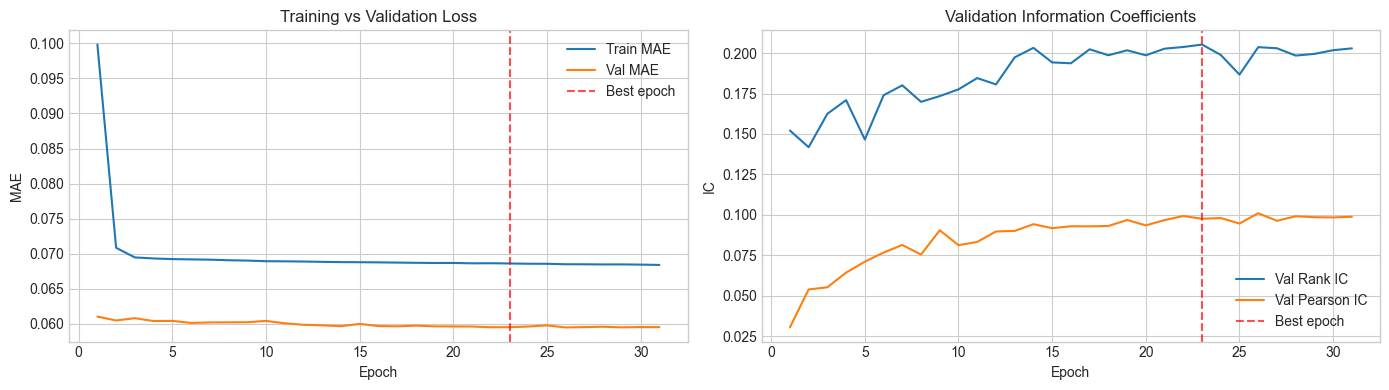

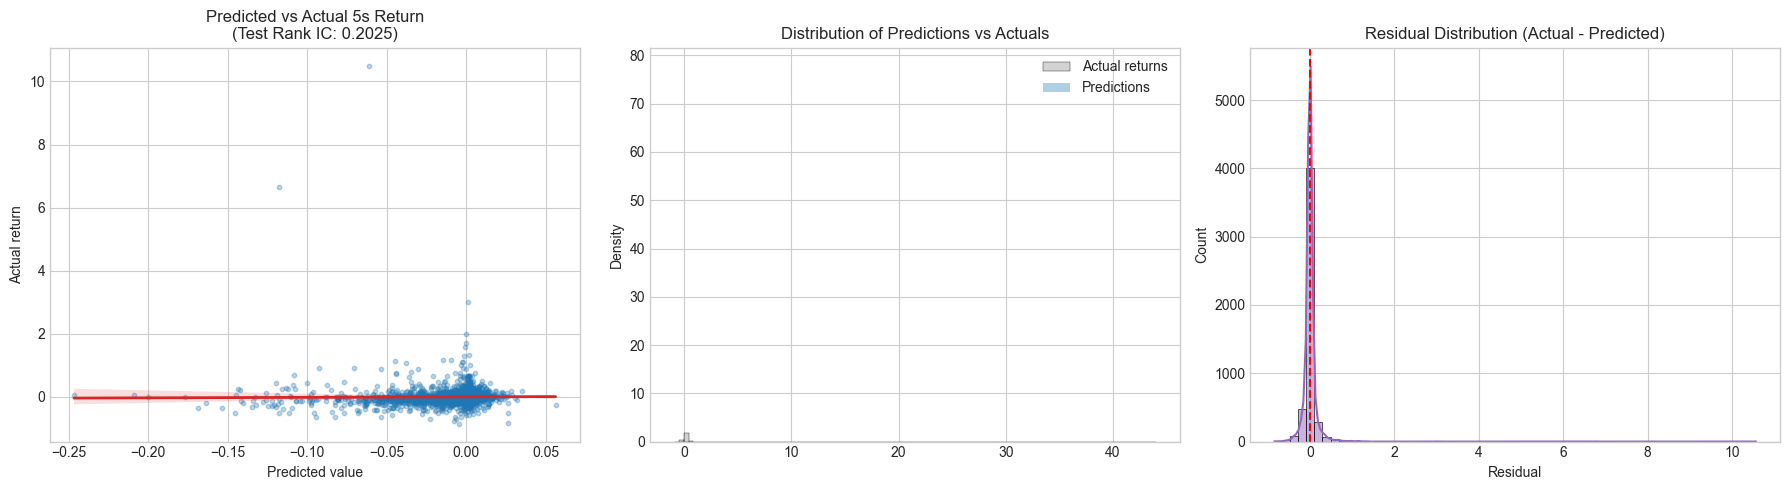

In [25]:
# ==========================================
# 10. Diagnostics
# Training curves plus prediction diagnostics on the test set.
# ==========================================
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_df.index + 1, history_df["train_loss"], label="Train MAE")
axes[0].plot(history_df.index + 1, history_df["val_loss"], label="Val MAE")
if best_epoch > 0:
    axes[0].axvline(best_epoch, color="red", linestyle="--", alpha=0.7, label="Best epoch")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE")
axes[0].legend()

axes[1].plot(history_df.index + 1, history_df["val_rank_ic"], label="Val Rank IC")
axes[1].plot(history_df.index + 1, history_df["val_pearson_ic"], label="Val Pearson IC")
if best_epoch > 0:
    axes[1].axvline(best_epoch, color="red", linestyle="--", alpha=0.7, label="Best epoch")
axes[1].set_title("Validation Information Coefficients")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("IC")
axes[1].legend()

plt.tight_layout()
plt.show()

sample_size = min(5000, len(test_preds))
sample_idx = np.random.choice(len(test_preds), sample_size, replace=False)
residuals = test_targets - test_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(
    x=test_preds[sample_idx],
    y=test_targets[sample_idx],
    ax=axes[0],
    scatter_kws={"alpha": 0.3, "s": 10, "color": "#1f77b4"},
    line_kws={"color": "#d62728", "linewidth": 2},
)
axes[0].set_title(f"Predicted vs Actual 5s Return\n(Test Rank IC: {test_metrics['rank_ic']:.4f})")
axes[0].set_xlabel("Predicted value")
axes[0].set_ylabel("Actual return")

sns.histplot(
    test_targets,
    bins=100,
    stat="density",
    color="gray",
    alpha=0.35,
    label="Actual returns",
    ax=axes[1],
)
sns.histplot(
    test_preds,
    bins=100,
    stat="density",
    color="#1f77b4",
    alpha=0.35,
    label="Predictions",
    ax=axes[1],
)
axes[1].set_title("Distribution of Predictions vs Actuals")
axes[1].legend()

sns.histplot(residuals[sample_idx], bins=60, kde=True, color="#9467bd", ax=axes[2])
axes[2].axvline(0.0, color="red", linestyle="--")
axes[2].set_title("Residual Distribution (Actual - Predicted)")
axes[2].set_xlabel("Residual")

plt.tight_layout()
plt.show()


Test backtest summary
total_samples: 67612
time_start: 2025-12-13 17:02:58+00:00
time_end: 2025-12-15 03:14:24+00:00
n_trades: 13524
trade_rate: 20.00%
n_long: 6762
n_short: 6762
signal_hit_rate: 57.56%
win_rate: 50.94%
gross_pnl_sum: 341.210328
trade_cost_sum: 155.312451
net_pnl_sum: 185.897877
avg_net_pnl_per_trade: 0.013746
avg_abs_prediction_traded: 0.030949441716074944
upper_threshold: 0.006741
lower_threshold: -0.021563
execution_price_non_null: 67612


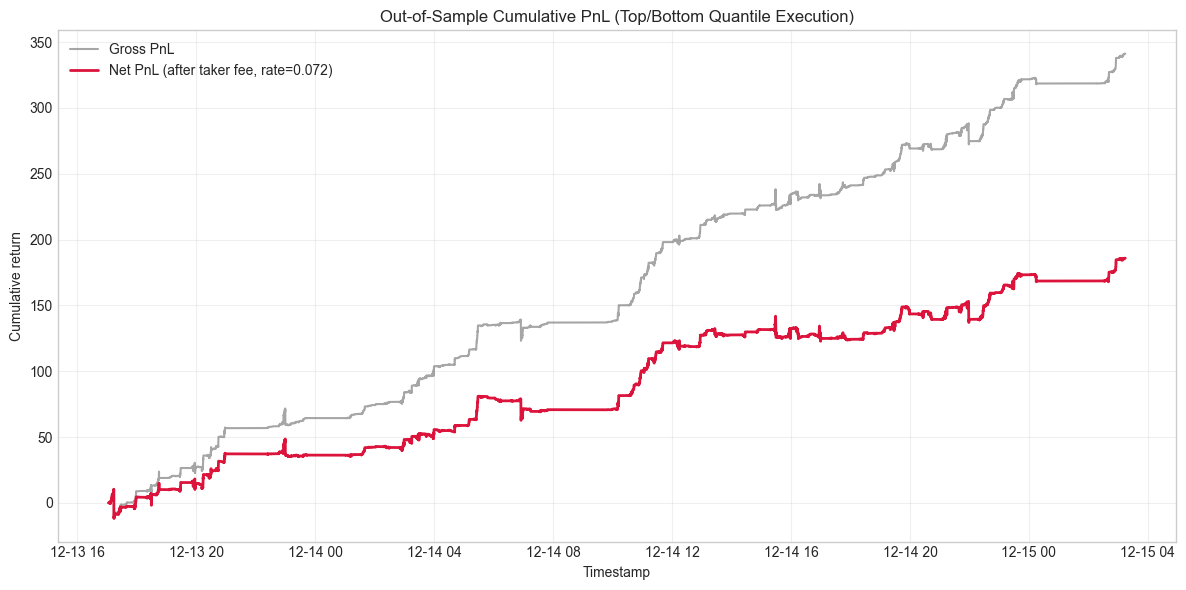

,slug,timestamp,execution_price,pred_signal,future_return,position,shares_traded,gross_pnl,trade_cost,net_pnl
34,btc-updown-15m-1765645200,2025-12-13 17:03:32+00:00,0.365,0.009880,0.000000,1,1.0,0.000000,0.016688,-0.016688
56,btc-updown-15m-1765645200,2025-12-13 17:03:54+00:00,0.165,0.009681,0.363636,1,1.0,0.363636,0.009920,0.353717
72,btc-updown-15m-1765645200,2025-12-13 17:04:10+00:00,0.190,0.008451,0.026316,1,1.0,0.026316,0.011081,0.015235
78,btc-updown-15m-1765645200,2025-12-13 17:04:16+00:00,0.195,0.009610,0.000000,1,1.0,0.000000,0.011302,-0.011302
109,btc-updown-15m-1765645200,2025-12-13 17:04:47+00:00,0.150,0.008945,0.066667,1,1.0,0.066667,0.009180,0.057487


In [26]:
# ==========================================
# 11. Threshold-based backtest
# Same backtest accounting and chronology checks as the updated LSTM notebook.
# ==========================================
TAKER_FEE_RATE = CONFIG["taker_fee_rate"]
UPPER_QUANTILE = CONFIG["upper_quantile"]
LOWER_QUANTILE = CONFIG["lower_quantile"]


def run_threshold_backtest(
    results_df,
    upper_quantile=0.90,
    lower_quantile=0.10,
    taker_fee_rate=0.072,
):
    bt_df = results_df.sort_values(["timestamp", "slug"]).reset_index(drop=True).copy()
    bt_df["execution_price"] = pd.to_numeric(bt_df["execution_price"], errors="coerce")

    if bt_df["execution_price"].isna().any():
        missing_count = int(bt_df["execution_price"].isna().sum())
        raise ValueError(
            f"execution_price has {missing_count} missing values. Please confirm ../data/LSTM_DATA_WITH_PRICE.parquet includes price data."
        )

    upper_threshold = bt_df["pred_signal"].quantile(upper_quantile)
    lower_threshold = bt_df["pred_signal"].quantile(lower_quantile)

    bt_df["position"] = 0
    bt_df.loc[bt_df["pred_signal"] >= upper_threshold, "position"] = 1
    bt_df.loc[bt_df["pred_signal"] <= lower_threshold, "position"] = -1

    bt_df["shares_traded"] = np.abs(bt_df["position"]).astype(float)
    bt_df["gross_pnl"] = bt_df["position"] * bt_df["future_return"]
    bt_df["trade_cost"] = (
        bt_df["shares_traded"]
        * taker_fee_rate
        * bt_df["execution_price"]
        * (1.0 - bt_df["execution_price"])
    )
    bt_df["net_pnl"] = bt_df["gross_pnl"] - bt_df["trade_cost"]

    trades_only = bt_df[bt_df["position"] != 0].copy()

    signal_hit_rate = (
        np.mean(np.sign(trades_only["pred_signal"]) == np.sign(trades_only["future_return"]))
        if len(trades_only) > 0
        else np.nan
    )
    win_rate = (trades_only["net_pnl"] > 0).mean() if len(trades_only) > 0 else np.nan

    summary = {
        "total_samples": len(bt_df),
        "time_start": bt_df["timestamp"].min(),
        "time_end": bt_df["timestamp"].max(),
        "n_trades": len(trades_only),
        "trade_rate": len(trades_only) / len(bt_df) if len(bt_df) > 0 else np.nan,
        "n_long": int((trades_only["position"] == 1).sum()),
        "n_short": int((trades_only["position"] == -1).sum()),
        "signal_hit_rate": signal_hit_rate,
        "win_rate": win_rate,
        "gross_pnl_sum": bt_df["gross_pnl"].sum(),
        "trade_cost_sum": bt_df["trade_cost"].sum(),
        "net_pnl_sum": bt_df["net_pnl"].sum(),
        "avg_net_pnl_per_trade": trades_only["net_pnl"].mean() if len(trades_only) > 0 else np.nan,
        "avg_abs_prediction_traded": (
            trades_only["pred_signal"].abs().mean() if len(trades_only) > 0 else np.nan
        ),
        "upper_threshold": upper_threshold,
        "lower_threshold": lower_threshold,
        "execution_price_non_null": int(bt_df["execution_price"].notna().sum()),
    }

    return bt_df, trades_only, summary


bt_df, trades_only, bt_summary = run_threshold_backtest(
    test_results_df,
    upper_quantile=UPPER_QUANTILE,
    lower_quantile=LOWER_QUANTILE,
    taker_fee_rate=TAKER_FEE_RATE,
)

print()
print("=" * 60)
print("Test backtest summary")
print("=" * 60)
for key, value in bt_summary.items():
    if isinstance(value, float):
        if "rate" in key or "hit" in key or "win" in key:
            print(f"{key}: {value:.2%}")
        else:
            print(f"{key}: {value:.6f}")
    else:
        print(f"{key}: {value}")

backtest_dataset = bt_df.copy()

plt.figure(figsize=(12, 6))
plt.plot(bt_df["timestamp"], bt_df["gross_pnl"].cumsum(), label="Gross PnL", color="gray", alpha=0.7)
plt.plot(
    bt_df["timestamp"],
    bt_df["net_pnl"].cumsum(),
    label=f"Net PnL (after taker fee, rate={TAKER_FEE_RATE})",
    color="crimson",
    linewidth=2,
)
plt.title("Out-of-Sample Cumulative PnL (Top/Bottom Quantile Execution)")
plt.xlabel("Timestamp")
plt.ylabel("Cumulative return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

trades_only.head()
